# Hotel reviews: exploratory analysis

3,720 TripAdvisor reviews of 23 Miami and Orlando hotels, 27% of them written in Spanish. This notebook checks the
data before trusting it, then looks at how English and Spanish reviewers differ. Method details are in
[`docs/METHODOLOGY.md`](../docs/METHODOLOGY.md).

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams.update({'figure.dpi': 100, 'axes.spines.top': False, 'axes.spines.right': False})
EN, ES = '#2b6cb0', '#dd6b20'

d = Path('..') / 'dashboard' / 'data'
reviews = pd.read_csv(d / 'processed_reviews.csv', parse_dates=['published_date'])
rep = pd.read_csv(d / 'reputation_scores.csv')
ment = pd.read_csv(d / 'aspect_mentions.csv')
lang = pd.read_csv(d / 'language_aspects.csv')
enes = reviews[reviews.language.isin(['en', 'es'])]
print(f"{len(reviews):,} reviews | {reviews.hotel_id.nunique()} hotels | {reviews.published_date.min():%b %Y} to {reviews.published_date.max():%b %Y}")
reviews.language.value_counts().head(4)

3,720 reviews | 23 hotels | May 2017 to Sep 2026


language
en    2670
es    1016
pt      13
fr       6
Name: count, dtype: int64

## Do English and Spanish reviewers rate differently?

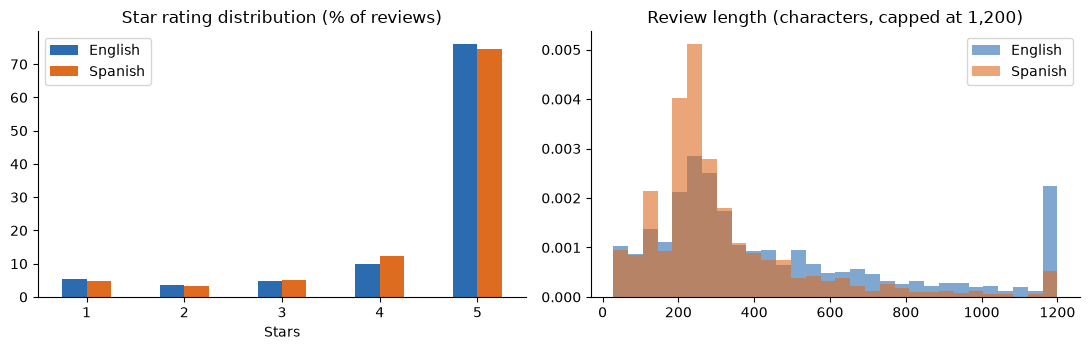

          avg_rating  median_chars  pct_5_star
language                                      
en              4.48         322.0       76.07
es              4.48         253.0       74.41


In [2]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
r = enes.groupby('language').rating.value_counts(normalize=True).unstack(0).mul(100)
r.plot.bar(ax=ax[0], color=[EN, ES], rot=0)
ax[0].set_title('Star rating distribution (% of reviews)'); ax[0].set_xlabel('Stars'); ax[0].legend(['English', 'Spanish'])
for code, color in (('en', EN), ('es', ES)):
    ax[1].hist(enes[enes.language == code].review_text.str.len().clip(upper=1200), bins=30, alpha=.6, color=color,
               density=True, label={'en': 'English', 'es': 'Spanish'}[code])
ax[1].set_title('Review length (characters, capped at 1,200)'); ax[1].legend()
plt.tight_layout(); plt.show()
print(enes.groupby('language').agg(avg_rating=('rating', 'mean'), median_chars=('review_text', lambda s: s.str.len().median()),
      pct_5_star=('rating', lambda s: 100 * (s == 5).mean())).round(2))

Star ratings are essentially identical across languages (average 4.48 in both), so any bilingual story has to
come from *what* guests write about, not how many stars they give. Spanish reviews are noticeably shorter, which
matters later: a shorter review has fewer chances to mention any given topic.

## Sanity check: does the sentiment model agree with star ratings?

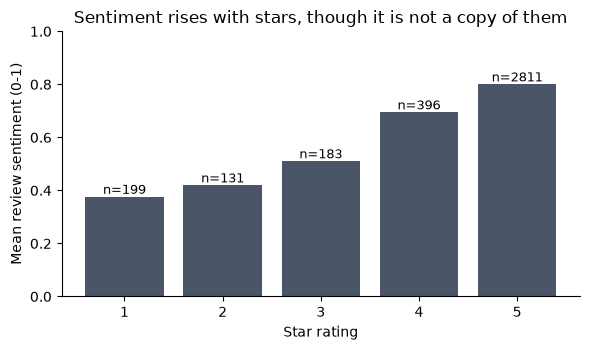

In [3]:
fig, ax = plt.subplots(figsize=(6, 3.6))
g = reviews.groupby('rating').sentiment_score.agg(['mean', 'count'])
ax.bar(g.index, g['mean'], color='#4a5568')
for x, (m, n) in g.iterrows(): ax.text(x, m + .01, f'n={int(n)}', ha='center', fontsize=9)
ax.set_xlabel('Star rating'); ax.set_ylabel('Mean review sentiment (0-1)'); ax.set_ylim(0, 1)
ax.set_title('Sentiment rises with stars, though it is not a copy of them')
plt.tight_layout(); plt.show()

Sentiment is computed from text only, never from the star rating, so this monotone relationship is independent
evidence the model is measuring something real. Only about 14% of reviews are rated 3 stars or lower (9% rated 1-2), so complaints are scarce.

## Hotel reputation scores

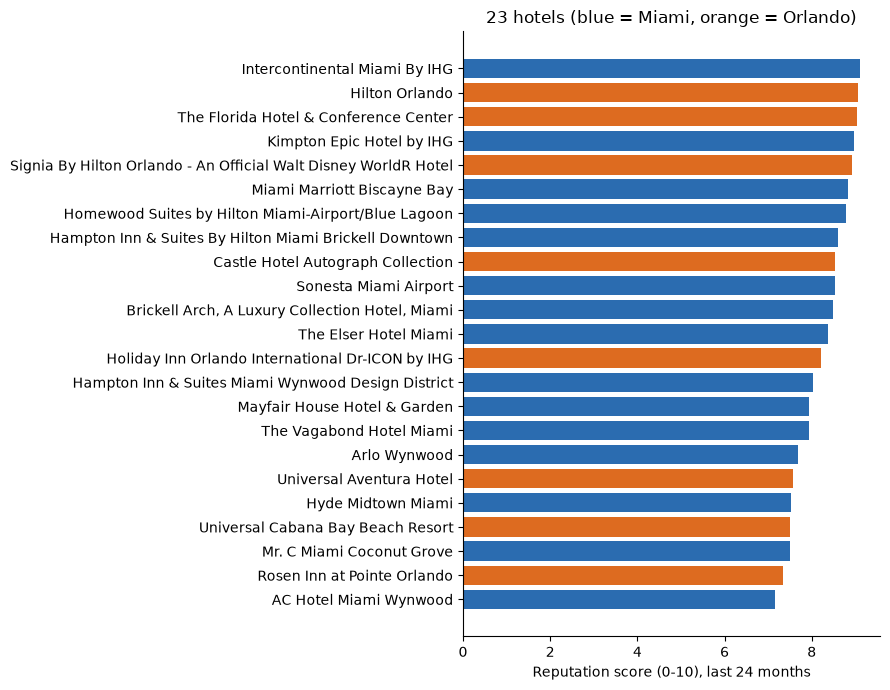

,count,mean,min,max
city,,,,
Miami,15,8.23,7.15,9.11
Orlando,8,8.27,7.33,9.05


In [4]:
fig, ax = plt.subplots(figsize=(9, 7))
s = rep.sort_values('reputation_score')
ax.barh(s.hotel_name, s.reputation_score, color=['#2b6cb0' if c == 'Miami' else '#dd6b20' for c in s.city])
ax.set_xlabel('Reputation score (0-10), last 24 months'); ax.set_title('23 hotels (blue = Miami, orange = Orlando)')
plt.tight_layout(); plt.show()
rep.groupby('city').reputation_score.agg(['count', 'mean', 'min', 'max']).round(2)

The score combines sentiment, star rating, recency and TripAdvisor review volume over a common 24-month window.
An earlier version scored over every scraped review; that made recency and volume measure how deep each hotel
happened to be scraped rather than anything about the hotel (see METHODOLOGY.md).

## What do guests complain about?

67 clear complaints out of 5,312 tagged sentences


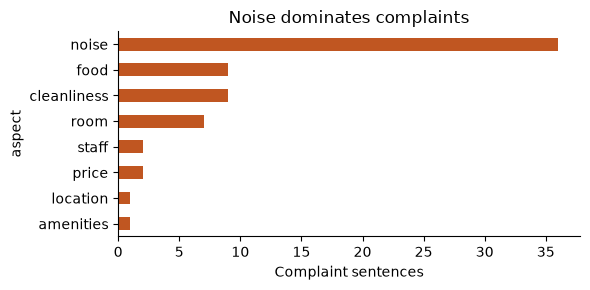

In [5]:
c = ment[ment.is_complaint]
print(f"{len(c)} clear complaints out of {len(ment):,} tagged sentences")
c.aspect.value_counts().plot.barh(color='#c05621', figsize=(6, 3)).invert_yaxis()
plt.xlabel('Complaint sentences'); plt.title('Noise dominates complaints'); plt.tight_layout(); plt.show()

## English vs Spanish: what do guests talk about?

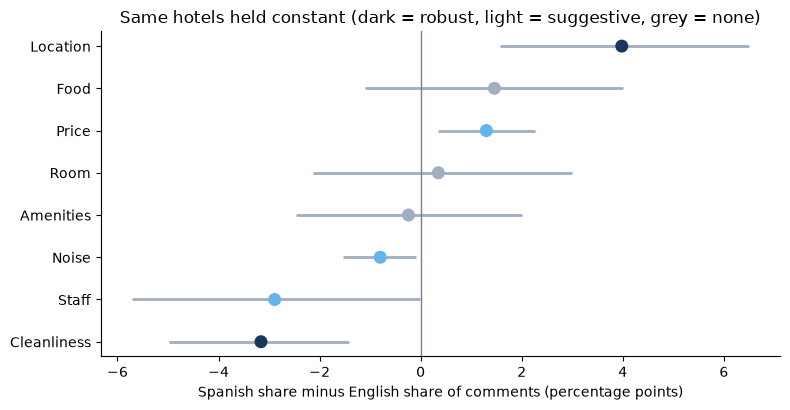

,aspect,en_share,es_share,raw_diff,adjusted_diff,ci_low,ci_high,evidence,hotels_same_direction
0,location,0.123,0.168,0.045,0.040,0.016,0.065,robust,10
1,food,0.151,0.183,0.032,0.015,-0.011,0.040,none,8
2,price,0.011,0.024,0.012,0.013,0.004,0.023,suggestive,7
3,room,0.198,0.208,0.010,0.004,-0.021,0.030,none,6
4,amenities,0.164,0.128,-0.035,-0.002,-0.025,0.020,none,7
5,noise,0.016,0.006,-0.010,-0.008,-0.015,-0.001,suggestive,7
6,staff,0.246,0.224,-0.022,-0.029,-0.057,-0.000,suggestive,10
7,cleanliness,0.091,0.058,-0.033,-0.032,-0.050,-0.014,robust,12


In [6]:
fig, ax = plt.subplots(figsize=(8, 4.2))
L = lang.sort_values('adjusted_diff')
colors = L.evidence.map({'robust': '#1a365d', 'suggestive': '#63b3ed', 'none': '#a0aec0'})
ax.errorbar(L.adjusted_diff * 100, range(len(L)), xerr=[(L.adjusted_diff - L.ci_low) * 100, (L.ci_high - L.adjusted_diff) * 100],
            fmt='none', ecolor='#a0aec0', lw=2, zorder=1)
ax.scatter(L.adjusted_diff * 100, range(len(L)), c=colors, s=70, zorder=2)
ax.axvline(0, color='#718096', lw=1); ax.set_yticks(range(len(L))); ax.set_yticklabels(L.aspect.str.capitalize())
ax.set_xlabel('Spanish share minus English share of comments (percentage points)')
ax.set_title('Same hotels held constant (dark = robust, light = suggestive, grey = none)')
plt.tight_layout(); plt.show()
lang[['aspect', 'en_share', 'es_share', 'raw_diff', 'adjusted_diff', 'ci_low', 'ci_high', 'evidence', 'hotels_same_direction']].round(3)

**Reading this.** Two differences hold up: Spanish-speaking guests give a larger share of their comments to
**location** and a smaller share to **cleanliness**, even when compared at the same hotels. Staff, price and noise
are suggestive at best. Food, room and amenities show no reliable difference; the apparent amenities and food gaps
in the raw comparison came from Spanish reviews clustering in particular hotels, not from language.

This shows *what* differs, not *why*, and trip type (family, business) is not yet controlled for.

Next: scrape the remaining Orlando hotels (7 more), then repeat the comparison with more Spanish reviews there.